In [94]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time 
from scipy.stats import norm
import QuantLib as ql

## Interest Rate Swaps

In [ ]:
# Setup dates & calendar
todays_date = ql.Date(1, 11, 2025)
ql.Settings.instance().evaluationDate = todays_date
calendar = ql.TARGET()
day_count = ql.Thirty360(ql.Thirty360.BondBasis)

# Choose upward-sloping pillars (in years)
pillars_yrs = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])

# Example: continuously-compounded zero rates that slope up
zeros_cc = np.array([0.045, 0.046, 0.0475, 0.049, 0.050, 0.052,
                     0.053, 0.054, 0.055, 0.056, 0.057])

# Build pillar dates from years (months ≈ years*12)
pillar_dates = [todays_date] + [
    calendar.advance(todays_date, ql.Period(int(round(y*12)), ql.Months))
    for y in pillars_yrs
]

# Year fractions for the chosen day count
pillar_t = np.array([0.0] + [day_count.yearFraction(todays_date, d) for d in pillar_dates[1:]])

# Convert zeros (cc) to discount factors: P(0,T) = exp(-z(T)*T)
discounts = [1.0] + list(np.exp(-zeros_cc * pillars_yrs))

# Build the curve from discount factors (bypasses compounding conventions)
disc_curve = ql.DiscountCurve(pillar_dates, discounts, day_count, calendar)
disc_curve.enableExtrapolation()
spot_curve_handle = ql.YieldTermStructureHandle(disc_curve)

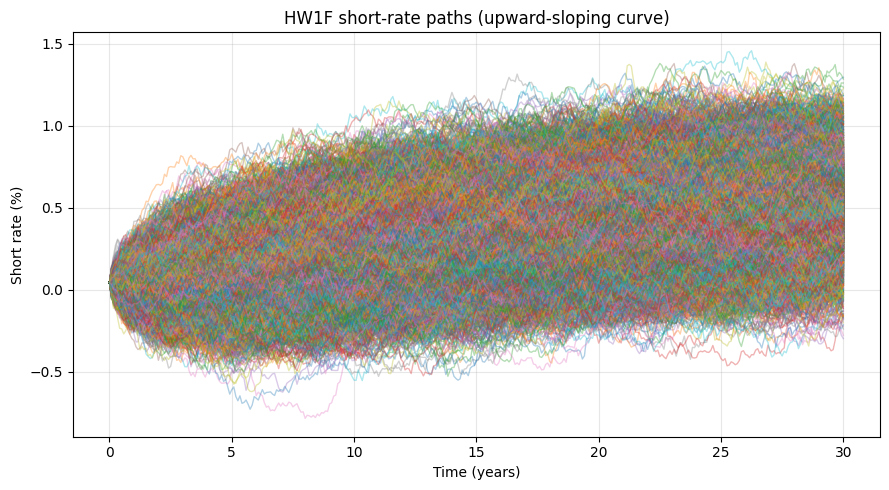

In [ ]:
# HW1F
a, sigma = 0.1, 0.1
hw_process = ql.HullWhiteProcess(spot_curve_handle, a, sigma)
def generate_paths(num_paths, timestep, seq):
    arr = np.zeros((num_paths, timestep+1))
    # time grid is same for every path
    path = seq.next().value()
    time = np.array([path.time(j) for j in range(len(path))])
    arr[0, :] = np.array([path[j] for j in range(len(path))])
    for i in range(1, num_paths):
        path = seq.next().value()
        arr[i, :] = np.array([path[j] for j in range(len(path))])
    return time, arr
timestep = 360
length = 30.0  # years
urng = ql.UniformRandomSequenceGenerator(timestep, ql.UniformRandomGenerator(12345))
grng = ql.GaussianRandomSequenceGenerator(urng)
seq = ql.GaussianPathGenerator(hw_process, length, timestep, grng, False)

# Simulate and plot
num_paths = 10000
times, paths = generate_paths(num_paths, timestep, seq)
plt.figure(figsize=(9,5))
plt.plot(times, paths.T, lw=1, alpha=0.35)
plt.xlabel("Time (years)"); plt.ylabel("Short rate (%)"); plt.title("HW1F short-rate paths (upward-sloping curve)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
def hw1f_bond_price(a, sigma, times, P0, f0, t, T, r_t, tol=1e-12):
    """
    Zero-coupon bond price under HW1F on a simulated path.
    Returns P(t,T). If T ~= t (within tol), returns 1.0.
    """
    # Handle coupon-date calls gracefully
    if np.isclose(T, t, atol=tol):
        return 1.0
    if T < t - tol:
        raise ValueError("Require T > t for a zero-coupon bond price.")

    # helpers: B(t,T) and A(t,T) as per HW1F
    def B(t_, T_):
        return (1.0 - np.exp(-a * (T_ - t_))) / a

    lnP0 = np.log(P0)
    lnP0_t = np.interp(t, times, lnP0)
    lnP0_T = np.interp(T, times, lnP0)
    f0_t   = np.interp(t, times, f0)

    BtT = B(t, T)

    # A(t,T) = P0(T)/P0(t) * exp( B f0(t) - (σ^2/(4a))*(1 - e^{-2 a t})*B^2 )
    A_tT = np.exp(lnP0_T - lnP0_t) * np.exp(
        BtT * f0_t - (sigma**2 / (4.0 * a)) * (1.0 - np.exp(-2.0 * a * t)) * (BtT**2)
    )

    return A_tT * np.exp(-BtT * r_t)



In [ ]:
def price_payer_swap_at_t(
    notional, K, schedule_T, delta,           
    t, r_t,                                   
    a, sigma, times, P0, f0,                  
    tol=1e-12
):
    """
    Payer swap clean PV at time t under HW1F along one path.
    Uses P(t,T) via hw1f_bond_price; avoids calling P(t,t) explicitly on coupon dates.
    """
    T = np.asarray(schedule_T, dtype=float)
    if np.isscalar(delta):
        delta_vec = np.full_like(T, float(delta))
    else:
        delta_vec = np.asarray(delta, dtype=float)

    # matured?
    if t >= T[-1] - tol:
        return 0.0, 0.0, 0.0

    # index of last coupon <= t
    j = np.searchsorted(T, t, side="right") - 1
    j = max(j, -1)

    def P_tU(U):
        return hw1f_bond_price(a, sigma, times, P0, f0, t, U, r_t, tol=tol)

    # Floating leg
    # On coupon dates (|T_j - t| <= tol): PV_float = N * [1 - P(t, T_N)]
    # Between coupons: PV_float = N * [P(t, T_j) - P(t, T_N)]
    if j >= 0 and np.isclose(T[j], t, atol=tol):
        PV_float = notional * (1.0 - P_tU(T[-1]))
    else:
        T_prev = T[j] if j >= 0 else t  # if before first coupon, treat T_prev = t
        PV_float = notional * (P_tU(T_prev) - P_tU(T[-1]))

    # Fixed leg: future coupons only
    future_idx = np.where(T > t + tol)[0]
    if future_idx.size == 0:
        return PV_float, 0.0, PV_float

    PV_fixed = notional * K * np.sum(
        delta_vec[future_idx] * np.array([P_tU(U) for U in T[future_idx]])
    )

    PV_swap = PV_float - PV_fixed
    return PV_swap, PV_fixed, PV_float

In [ ]:
def calculate_mtm_matrix_swap_hw1f_using_funcs(
    r_paths,                # (n_paths, N_times) short-rate paths
    times,                  # (N_times,) time grid in years (MUST include all coupon dates)
    schedule_T,             # (N_coupons,) coupon payment times [T1,...,TN]
    delta,                  # scalar or (N_coupons,) accruals
    notional, K,            # swap notional and fixed rate
    a, sigma,               # HW1F params
    P0, f0                  # today’s P(0,t) on 'times' and f0(t) = -d/dt ln P0
):
    """
    Returns:
      mtm_matrix : (n_paths, N_times) payer-swap PVs marked ONLY at coupon dates (clean price).
                   Non-coupon entries are 0.0 (so EE/EPE can sample on coupon dates).
      time_vector: (N_times,)
    """
    r_paths = np.asarray(r_paths, float)
    times   = np.asarray(times, float)
    n_paths, N = r_paths.shape
    if N != times.size:
        raise ValueError("r_paths and times must align in length")

    # ensure arrays
    T = np.asarray(schedule_T, float)
    if np.isscalar(delta):
        delta_vec = np.full_like(T, float(delta))
    else:
        delta_vec = np.asarray(delta, float)
        if delta_vec.shape != T.shape:
            raise ValueError("delta must be scalar or same shape as schedule_T")

    # map coupon dates to grid indices (require hits within tiny tolerance)
    tol = 1e-12
    coupon_idx = []
    for Ti in T:
        hits = np.where(np.abs(times - Ti) <= tol)[0]
        if hits.size == 0:
            raise ValueError("All coupon dates must lie on the 'times' grid")
        coupon_idx.append(int(hits[0]))
    coupon_idx = np.array(coupon_idx, dtype=int)

    mtm_matrix = np.zeros((n_paths, N), dtype=float)

    # value ONLY on coupon dates to avoid P(t, t) / T_prev < t issues
    for t_idx in coupon_idx:
        t = times[t_idx]
        if t >= T[-1]:
            continue
        r_vec = r_paths[:, t_idx]

        # call  pricer per path; it will in turn call hw1f_bond_price
        pv_list = [
            price_payer_swap_at_t(
                notional, K, T, delta_vec,
                t, r_i,
                a, sigma, times, P0, f0
            )[0]   # take PV_swap
            for r_i in r_vec
        ]
        mtm_matrix[:, t_idx] = np.array(pv_list, dtype=float)

    return mtm_matrix, times


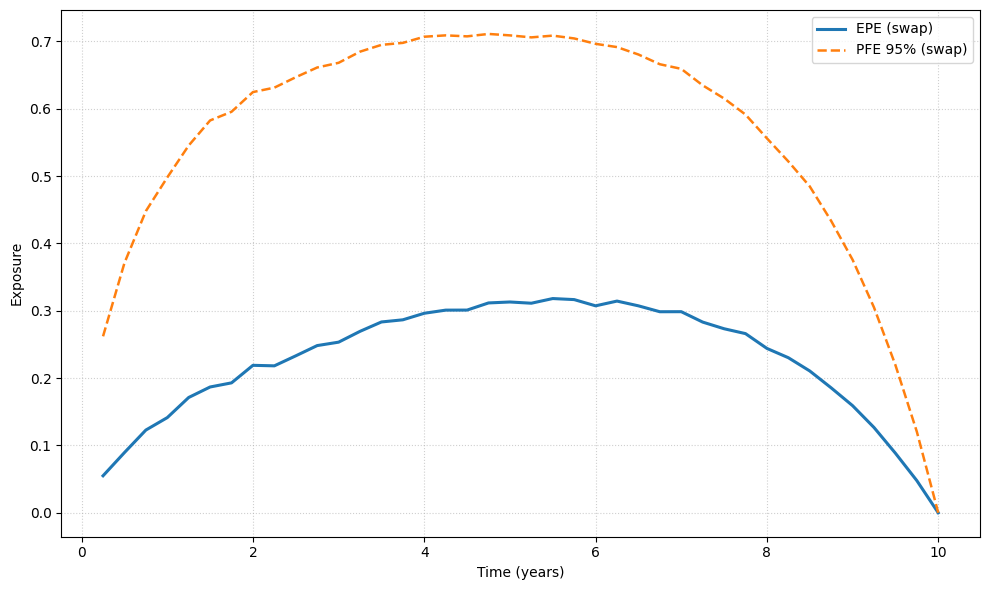

In [ ]:
# Build P0 and f0 on the SAME grid as  HW paths
dates_for_times = [
    calendar.advance(todays_date, ql.Period(int(round(t*360)), ql.Days))
    for t in times
]
P0 = np.array([spot_curve_handle.discount(d) for d in dates_for_times], dtype=float)

lnP0 = np.log(P0)
f0 = np.empty_like(times)
f0[1:-1] = -(lnP0[2:] - lnP0[:-2]) / (times[2:] - times[:-2])   # central diff
f0[0]  = f0[1]
f0[-1] = f0[-2]

# Define the swap (payer) schedule & fixed rate
maturity = 10.0
delta = 0.25
schedule_T = np.arange(delta, maturity + 1e-12, delta)   # [0.25, 0.5, ..., 10.0]

def par_swap_rate_from_P0(times, lnP0, schedule_T, delta):
    lnP_T = np.interp(schedule_T, times, lnP0)
    P_T   = np.exp(lnP_T)
    denom = np.sum(delta * P_T)
    return (1.0 - P_T[-1]) / denom

notional = 1.0
K_par = par_swap_rate_from_P0(times, lnP0, schedule_T, delta)
K = K_par    # or set to any strike 

# MtM matrix for the payer swap along HW paths (calls helper functions)
mtm_matrix_swap, time_vec = calculate_mtm_matrix_swap_hw1f_using_funcs(
    r_paths=paths,
    times=times,
    schedule_T=schedule_T,
    delta=delta,
    notional=notional,
    K=K,
    a=a,
    sigma=sigma,
    P0=P0,
    f0=f0
)

# Exposure profiles (EE, PFE) exactly like European flow
position = 1   # +1 if you hold the payer swap; -1 if opposite sign
mtm_final_swap = mtm_matrix_swap * position

x_swap = np.maximum(mtm_final_swap, 0.0)
EE_swap  = np.mean(x_swap, axis=0)                # (N_times,)
SE_swap = x_swap.std(axis=0, ddof=1) / np.sqrt(max(num_paths, 1))
PFE_swap = np.quantile(np.maximum(mtm_final_swap, 0.0), 0.95, axis=0)      # (N_times,)


tol = 1e-12
coupon_idx = []
for Ti in schedule_T:
    hit = np.where(np.abs(time_vec - Ti) <= tol)[0][0]
    coupon_idx.append(int(hit))
coupon_idx = np.array(coupon_idx)

plt.figure(figsize=(10,6))
plt.plot(time_vec[coupon_idx], EE_swap[coupon_idx],  lw=2.2, label="EPE (swap)")
plt.plot(time_vec[coupon_idx], PFE_swap[coupon_idx], lw=1.8, ls="--", label="PFE 95% (swap)")
plt.xlabel("Time (years)"); plt.ylabel("Exposure"); plt.grid(True, ls=":", alpha=0.6); plt.legend(); plt.tight_layout()

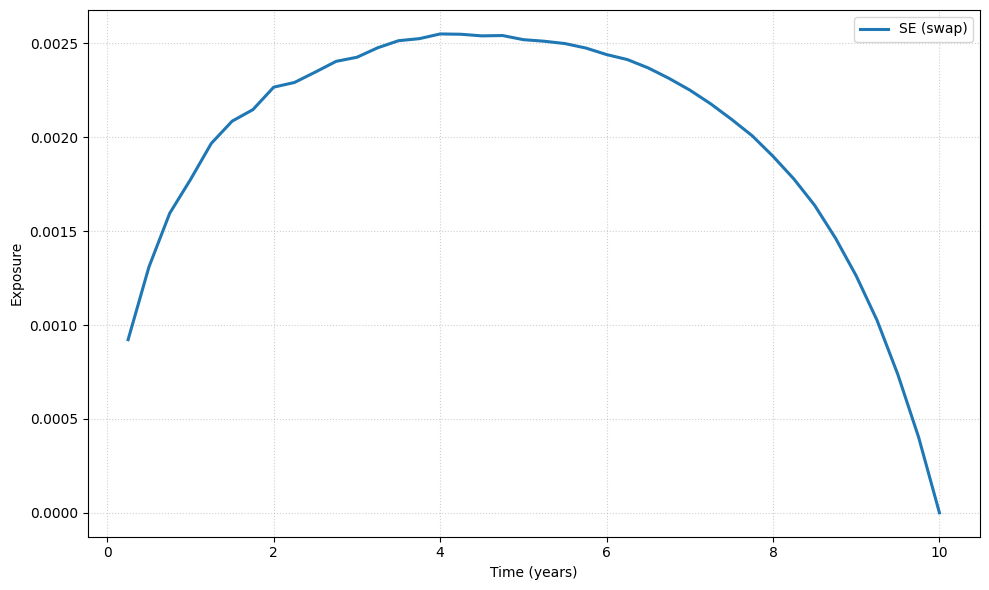

In [101]:
plt.figure(figsize=(10,6))
plt.plot(time_vec[coupon_idx], SE_swap[coupon_idx],  lw=2.2, label="SE (swap)")
plt.xlabel("Time (years)"); plt.ylabel("Exposure"); plt.grid(True, ls=":", alpha=0.6); plt.legend(); plt.tight_layout()

## European Options

In [102]:
def gbm_path_sim_vectorized(
    s_start, r, sigma, T_sim, n_sims, m_steps, Z_matrix=None
):
    """
    Simulates Geometric Brownian Motion paths using a vectorized numpy approach.
    
    Can optionally accept a pre-generated matrix of standard normal
    random numbers (Z_matrix) for variance reduction techniques.
    
    s_start: Initial asset price (S_t)
    r: Risk-free interest rate
    sigma: Volatility
    T_sim: Time horizon for the simulation (e.g., T_remaining)
    n_sims: Number of simulation paths (N)
    m_steps: Number of time steps (M_remaining)
    Z_matrix (np.ndarray, optional): A pre-generated (n_sims, m_steps) matrix
                                     of standard normal random numbers.
    """
    
    dt = T_sim / m_steps
    
    # 1. Get the random numbers
    if Z_matrix is None:
        # If no matrix is provided, generate one
        Z = np.random.normal(0.0, 1.0, (n_sims, m_steps))
    else:
        # If a matrix is provided, use it
        # (A good practice check to ensure shapes match)
        if Z_matrix.shape != (n_sims, m_steps):
            raise ValueError(f"Z_matrix shape {Z_matrix.shape} does not match (n_sims, m_steps) {(n_sims, m_steps)}")
        Z = Z_matrix
    
    # 2. Calculate all log-returns in one go
    # Shape: (n_sims, m_steps)
    log_returns = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z
    
    # 3. Calculate the cumulative sum of log-returns across time (axis=1)
    # Shape: (n_sims, m_steps)
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    
    # 4. Create the output matrix and set the start price
    # Shape: (n_sims, m_steps + 1)
    simulated_paths = np.zeros((n_sims, m_steps + 1))
    simulated_paths[:, 0] = s_start
    
    # 5. Exponentiate and multiply by s_start to get all prices from t=1 to t=M
    # This fills all columns from index 1 onwards
    simulated_paths[:, 1:] = s_start * np.exp(cumulative_log_returns)
            
    # Return the complete matrix of paths
    return simulated_paths

def bsm_price(s_start, k, r, sigma, t_current, T_maturity, omega):
    """
    Calculates the Black-Scholes-Merton price for European options
    with consistent argument names.

    This function is vectorized. 's_start', 'k', 'r', and 'sigma' can be
    numpy arrays, while 't_current', 'T_maturity', and 'omega' are scalars.

    Args:
        s_start (float or np.ndarray): Current spot price(s) of the underlying.
        k (float or np.ndarray): Strike price(s).
        r (float or np.ndarray): Risk-free interest rate(s).
        sigma (float or np.ndarray): Volatility (annualized).
        t_current (float): Current time (in years).
        T_maturity (float): Time to maturity (in years).
        omega (int): Option type: 1 for a call, -1 for a put.

    Returns:
        float or np.ndarray: The BSM price(s) of the option(s).
    """
    
    # --- Input Validation ---
    if omega not in (1, -1):
        raise ValueError("omega must be 1 (call) or -1 (put)")

    tau = T_maturity - t_current
    
    if np.any(tau <= 0):
        raise ValueError("T_maturity must be greater than t_current (tau must be > 0)")

    # --- BSM Formula ---
    
    # Calculate d1 and d2
    d_1 = (np.log(s_start / k) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d_2 = d_1 - sigma * np.sqrt(tau)

    # Calculate price using the generalized call/put formula
    # norm.cdf() is the Python equivalent of R's pnorm()
    price = omega * (s_start * norm.cdf(omega * d_1) - k * np.exp(-r * tau) * norm.cdf(omega * d_2))

    return price


In [103]:
def calculate_mtm_matrix_european(
    all_paths: np.ndarray, 
    k: float, 
    r: float, 
    sigma: float, 
    T_maturity: float, 
    omega: int
):
    """
    Calculates the MtM matrix for a European option given pre-simulated paths.
    
    Args:
        all_paths (np.ndarray): The (n_sims, m_steps + 1) matrix of simulated prices.
        k (float): Strike price.
        r (float): Risk-free rate.
        sigma (float): Volatility.
        T_maturity (float): Original time to maturity.
        omega (int): 1 for call, -1 for put.

    Returns:
        mtm_matrix (np.ndarray): The (n_sims, m_steps + 1) matrix of MtM values.
        time_vector (np.ndarray): The (m_steps + 1) vector of time points.
    """
    
    # 1. Get shape and time info from the paths matrix
    n_sims, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1
    
    # 2. Create helper variables
    mtm_matrix = np.zeros_like(all_paths)
    time_vector = np.linspace(0, T_maturity, m_steps + 1)
    
    print("Calculating MtM matrix (pricing at each time step)...")
    # 3. Loop through TIME (columns), not paths
    # We loop from t=0 up to t=M-1 (the step *before* maturity)
    for j in range(m_steps):
        t_current = time_vector[j]
        
        # Get the vector of all spot prices at this time step
        s_at_tj = all_paths[:, j]
        
        # Call the BSM pricer ONCE on the entire vector of paths
        mtm_matrix[:, j] = bsm_price(
            s_start=s_at_tj, 
            k=k, r=r, sigma=sigma, 
            t_current=t_current, 
            T_maturity=T_maturity, 
            omega=omega
        )
        
    # 4. Handle the final time step (t=T) manually as a payoff
    # Get the spot prices at maturity
    s_at_T = all_paths[:, m_steps]
    mtm_matrix[:, m_steps] = np.maximum(omega * (s_at_T - k), 0)
    
    print("MtM calculation complete.")
    return mtm_matrix, time_vector

In [ ]:
# Set Parameters
s_start = 100
k = 100
r = 0.05
sigma = 0.2
T_maturity = 1.0
n_sims = 10000  
m_steps = 250         
omega = 1            # 1 for a Call option
position = 1         # 1 for LONG

np.random.seed(42)

print("--- xVA Simulation Start ---")
print(f"Outer Paths: {n_sims}, Time Steps: {m_steps}")


# Simulate paths
print("\nStep 1: Simulating all paths...")
start_time = time.time()
all_paths = gbm_path_sim_vectorized(s_start, r, sigma, T_maturity, n_sims, m_steps)
end_time = time.time()
print(f"GBM path simulation complete. Took {end_time - start_time:.4f} seconds.")

# Get MtM for European Option
print("\nStep 2: Calculating MtM for European Option (FAST, vectorized)...")
start_time = time.time()
mtm_matrix_euro, time_vector = calculate_mtm_matrix_european(
    all_paths=all_paths, k=k, r=r, sigma=sigma, 
    T_maturity=T_maturity, omega=omega
)
end_time = time.time()
print(f"Calculation complete. Took {end_time - start_time:.4f} seconds.")


--- xVA Simulation Start ---
Outer Paths: 10000, Time Steps: 250

Step 1: Simulating all paths...
GBM path simulation complete. Took 0.0723 seconds.

Step 2: Calculating MtM for European Option (FAST, vectorized)...
Calculating MtM matrix (pricing at each time step)...
MtM calculation complete.
Calculation complete. Took 0.1676 seconds.



Step 5: Calculating Exposure Profiles...

[Plotting results...]


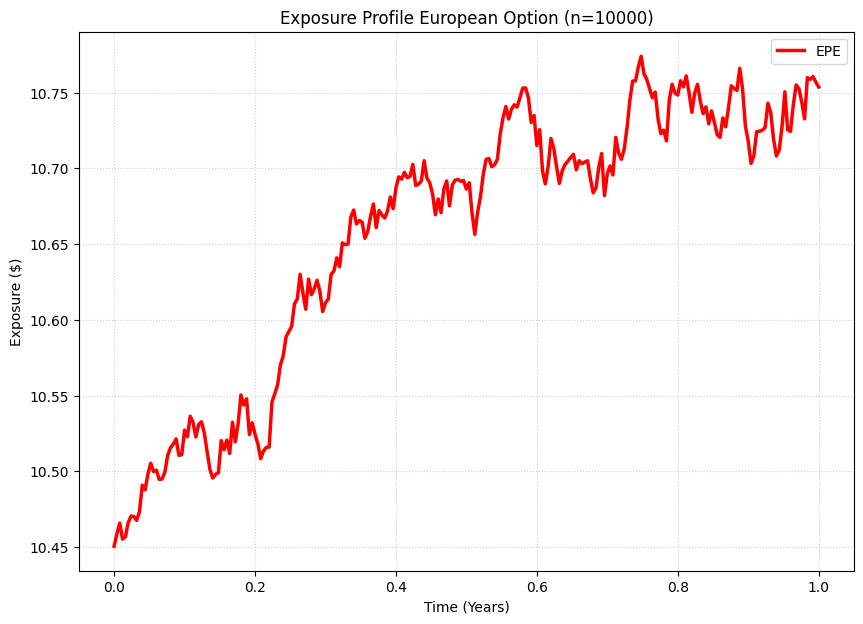

In [ ]:

# Apply Position 
mtm_final_euro = mtm_matrix_euro * position


# Calculate Exposure Profiles
print("\nStep 5: Calculating Exposure Profiles...")
x_euro = np.maximum(mtm_final_euro, 0)
ee_profile_euro = np.mean(x_euro, axis=0)
se_profile_euro = x_euro.std(axis=0, ddof=1) / np.sqrt(max(n_sims, 1))
pfe_profile_euro = np.quantile(np.maximum(mtm_final_euro, 0), 0.95, axis=0)





# Plot the results
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

# Plot European (Fast)
plt.plot(time_vector, ee_profile_euro, label="EPE", color="red", linewidth=2.5)

plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)


[Plotting results...]


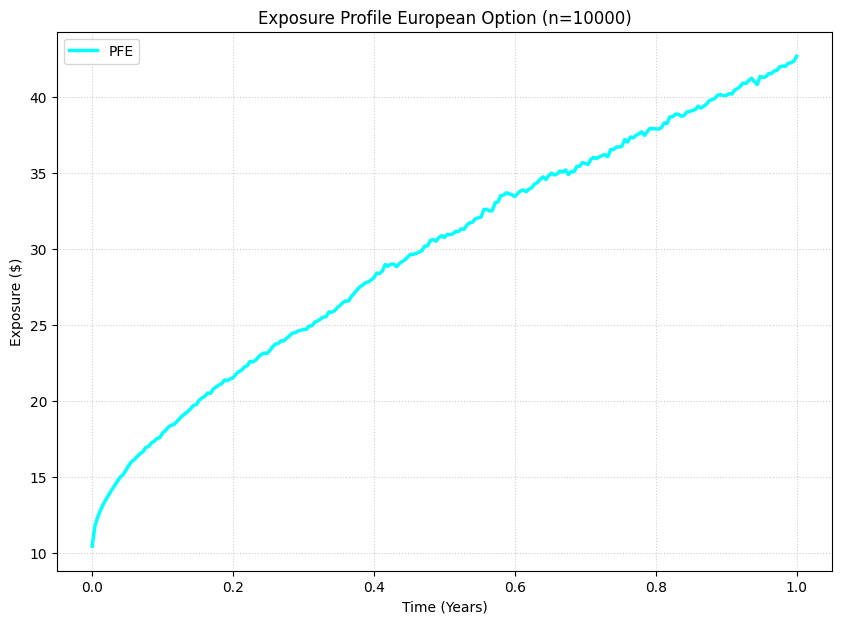

In [107]:
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

plt.plot(time_vector, pfe_profile_euro, label="PFE", color="cyan", linewidth=2.5)

plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)


[Plotting results...]


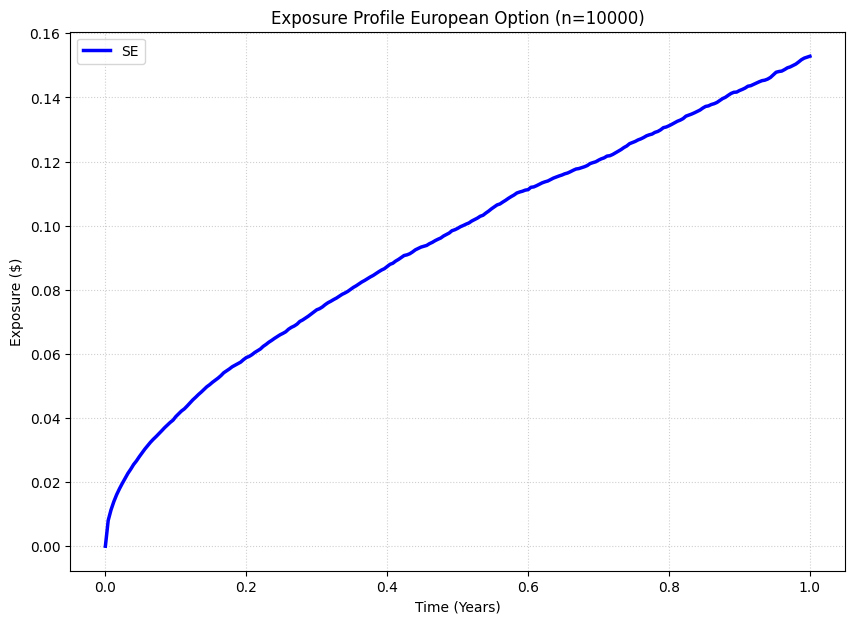

In [ ]:
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

# Plot European (Fast)
plt.plot(time_vector, se_profile_euro, label="SE", color="blue", linewidth=2.5)

plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

## Asian Options

In [ ]:

def price_asian_option_mc(
    s_current, k, r, sigma, T_maturity, n_sims, m_total_steps, omega, 
    t_current=0.0, historical_prices=None, Z_matrix=None
):
    """
    Prices an Asian Option (Call or Put) using Monte Carlo.
    Can handle both t=0 and t>0 (seasoned) options.
    
    Can optionally accept a Z_matrix for variance reduction.
    """
    
    if omega not in (1, -1):
        raise ValueError("omega must be 1 (call) or -1 (put)")
    
    #  1. Determine state (t=0 or t>0)
    if historical_prices is None or len(historical_prices) == 0:
        sum_known = 0.0
        m_known_steps = 0
        T_remaining = T_maturity - t_current
    else:
        historical_prices = np.asarray(historical_prices)
        sum_known = np.sum(historical_prices)
        m_known_steps = len(historical_prices)
        T_remaining = T_maturity - t_current
    
    m_remaining_steps = m_total_steps - m_known_steps

    # 2. Simulate Future Paths (if necessary) 
    if m_remaining_steps > 0:
        # *** UPDATED: Calls the new function name 'gbm_path_generator' ***
        all_future_paths = gbm_path_sim_vectorized(
            s_current, r, sigma, T_remaining, n_sims, m_remaining_steps,
            Z_matrix=Z_matrix
        )
        simulated_future_prices = all_future_paths[:, 1:]
        sum_future = np.sum(simulated_future_prices, axis=1)
        total_sum = sum_known + sum_future
        s_ave = total_sum / m_total_steps
    else:
        # No simulation needed. The average is already 100% known.
        s_ave = sum_known / m_total_steps
    
    # --- 3. Calculate Payoffs ---
    payoffs = np.maximum(omega * (s_ave - k), 0)
    
    # --- 4. Aggregate Results ---
    price = np.mean(payoffs) * np.exp(-r * T_remaining)
    
    return price

In [110]:
def calculate_mtm_matrix_asian(
    all_paths: np.ndarray,
    k: float,
    r: float,
    sigma: float,
    T_maturity: float,
    omega: int,
    n_sims_inner: int
):
    """
    Calculates the MtM matrix for an Asian option given pre-simulated paths.
    
    This uses a "nested" or "simulation-in-a-simulation" approach.
    """
    
    # 1. Get shape and time info
    n_sims_outer, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1 # m_steps is the m_total_steps for the option
    
    # 2. Create helper variables
    mtm_matrix = np.zeros_like(all_paths)
    time_vector = np.linspace(0, T_maturity, m_steps + 1)
    
    # 3. Loop through TIME (columns)
    for j in range(m_steps + 1): # Loop includes maturity date
        t_current = time_vector[j]
        
        if j % 20 == 0 or j == m_steps:
             print(f"  Pricing time step {j}/{m_steps}...")
        
        # 4. Loop through PATHS (rows)
        for i in range(n_sims_outer):
            
            # Get the state variables for this one node (i, j)
            s_current_i = all_paths[i, j]
            
            # History is S1...Sj (note the slice [:, 1:j+1])
            # At j=0, this is an empty slice, which is correct.
            hist_prices_i = all_paths[i, 1:j+1]
            
            # Call the inner MC pricer
            price_i = price_asian_option_mc(
                s_current=s_current_i,
                k=k, r=r, sigma=sigma,
                T_maturity=T_maturity,
                n_sims=n_sims_inner,
                m_total_steps=m_steps,
                omega=omega,
                t_current=t_current,
                historical_prices=hist_prices_i
            )
            
            mtm_matrix[i, j] = price_i
            
    return mtm_matrix, time_vector

--- xVA Simulation Start ---
Outer Paths: 10000, Time Steps: 250, Inner Paths: 100

Step 1: Simulating all 'outer' paths...
GBM path simulation complete. Took 0.1305 seconds.

Step 4: Calculating MtM for Asian Option (SLOW, nested MC)...
  Pricing time step 0/250...
  Pricing time step 20/250...
  Pricing time step 40/250...
  Pricing time step 60/250...
  Pricing time step 80/250...
  Pricing time step 100/250...
  Pricing time step 120/250...
  Pricing time step 140/250...
  Pricing time step 160/250...
  Pricing time step 180/250...
  Pricing time step 200/250...
  Pricing time step 220/250...
  Pricing time step 240/250...
  Pricing time step 250/250...
Calculation complete. Took 814.0936 seconds.

Step 5: Calculating Exposure Profiles...

[Plotting results...]

[Plot saved to 'exposure_comparison_plot.png']


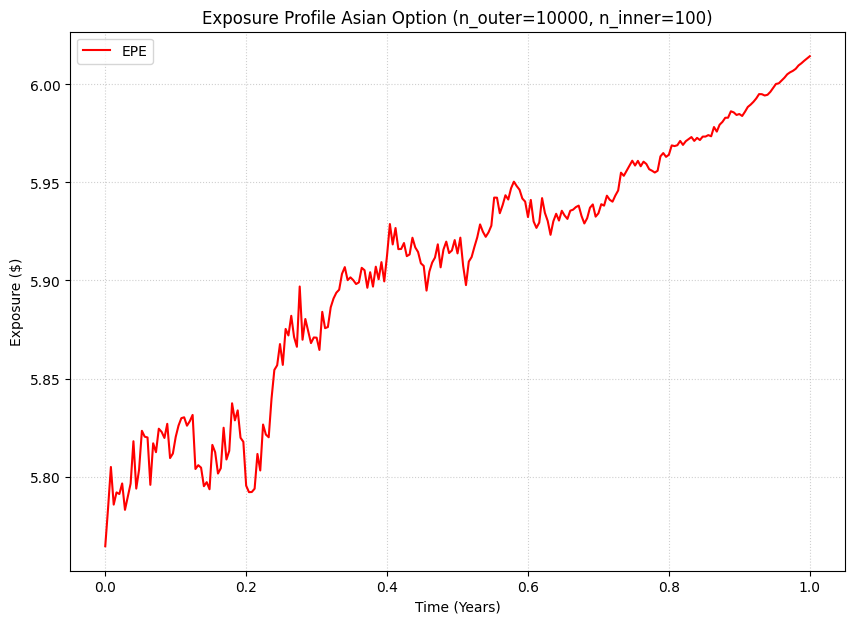

In [ ]:
# Set Parameters
s_start = 100
k = 100
r = 0.05
sigma = 0.2
T_maturity = 1.0
n_sims_outer = 10000 
m_steps = 250         
n_sims_inner = 100   
omega = 1            # 1 for a Call option
position = 1         # 1 for LONG

np.random.seed(42)

print("--- xVA Simulation Start ---")
print(f"Outer Paths: {n_sims_outer}, Time Steps: {m_steps}, Inner Paths: {n_sims_inner}")


# Run the "Outer Simulation" ONCE 
print("\nStep 1: Simulating all 'outer' paths...")
start_time = time.time()
all_paths = gbm_path_sim_vectorized(s_start, r, sigma, T_maturity, n_sims_outer, m_steps)
end_time = time.time()
print(f"GBM path simulation complete. Took {end_time - start_time:.4f} seconds.")

# Get MtM for Asian Option (Slow)
print("\nStep 4: Calculating MtM for Asian Option (SLOW, nested MC)...")
start_time = time.time()
mtm_matrix_asian, _ = calculate_mtm_matrix_asian(
    all_paths=all_paths, k=k, r=r, sigma=sigma,
    T_maturity=T_maturity, omega=omega, n_sims_inner=n_sims_inner
)
end_time = time.time()
print(f"Calculation complete. Took {end_time - start_time:.4f} seconds.")

# Apply Position
mtm_final_asian = mtm_matrix_asian * position


# -Calculate Exposure Profiles
print("\nStep 5: Calculating Exposure Profiles...")
x = np.maximum(mtm_final_asian, 0)
ee_profile_asian = np.mean(x, axis=0)
se_profile_asian = x.std(axis=0, ddof=1) / np.sqrt(max(n_sims_outer, 1))
pfe_profile_asian = np.quantile(np.maximum(mtm_final_asian, 0), 0.95, axis=0)


# (Optional) Plot the results
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

#  Plot Asian
plt.plot(time_vector, ee_profile_asian, label="EPE", color="red")

plt.title(f"Exposure Profile Asian Option (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)




[Plotting results...]

[Plot saved to 'exposure_comparison_plot.png']


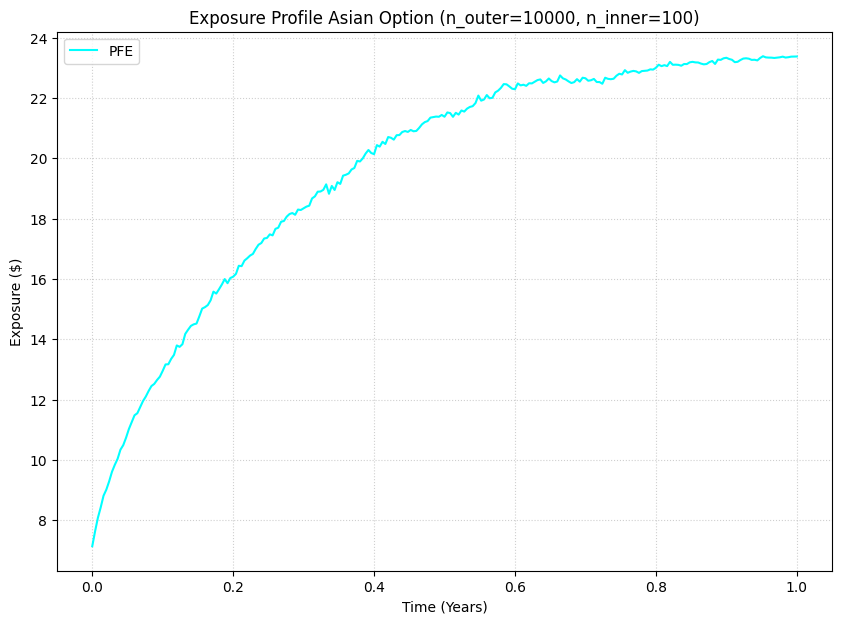

In [ ]:
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

# Plot Asian
plt.plot(time_vector, pfe_profile_asian, label="PFE", color="cyan")

plt.title(f"Exposure Profile Asian Option (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)



[Plotting results...]



[Plot saved to 'exposure_comparison_plot.png']


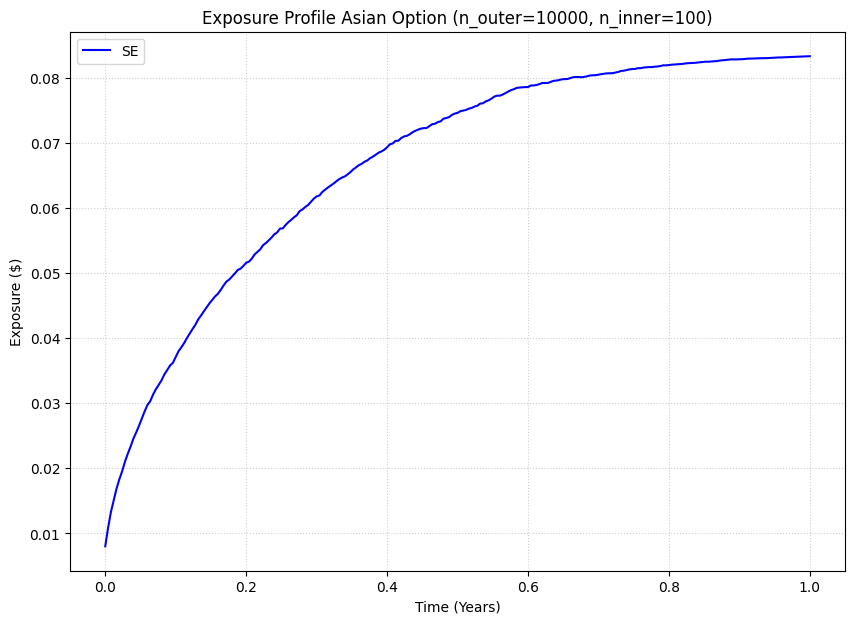

In [ ]:
print("\n[Plotting results...]")

plt.figure(figsize=(10, 7))

# Plot Asian
plt.plot(time_vector, se_profile_asian, label="SE", color="blue")

plt.title(f"Exposure Profile Asian Option (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
